# 07 — Streaming Simulation

This notebook demonstrates Sentinel's `StreamingSimulation` module, which simulates real-time data streaming with anomaly detection and live visualization.

### What is streaming anomaly detection?

In production systems, data doesn't arrive all at once — it streams in continuously. A streaming anomaly detector must:

1. **Ingest data in chunks** as it arrives (not wait for the full dataset)
2. **Maintain a sliding window** of recent history to define "normal"
3. **Score each new chunk** against the current model
4. **Adapt over time** as the data distribution shifts (optional dynamic thresholds)

Sentinel's `StreamingSimulation` wraps all of this into a single class that feeds data from a DataFrame, runs an internal `IsolationForest` detector, and renders a live-updating chart.

### Architecture overview

| Component | Role |
|-----------|------|
| `StreamingDataManager` | Feeds data in chunks from a DataFrame, simulating real-time arrival |
| `AnomalyDetector` | Internal IsolationForest that trains on the first window and scores each subsequent chunk |
| `StreamingSimulation` | Orchestrates streaming, detection, and live plotting |

### Two execution modes

| Method | Environment | How it works |
|--------|-------------|-------------|
| `run()` | Terminal / Python script | Uses `plt.ion()` + background threads for a native matplotlib window |
| `run_notebook()` | Jupyter notebook | Uses `IPython.display.clear_output` to animate inline — no extra backend needed |

> This notebook uses `run_notebook()` so you can see the animation directly in the output cell.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

---
## 1. Generate Synthetic Streaming Data

We create a time-indexed DataFrame simulating server metrics arriving over time:

- **2000 data points** at 1-minute intervals (~33 hours)
- **Periodic patterns**: CPU follows a daily sine wave, memory follows a 12-hour cycle
- **3 anomaly bursts** injected at known positions — these simulate real incidents where all metrics spike simultaneously

The red-shaded regions in the plot below mark the injected anomaly bursts. A good streaming detector should flag these regions as they arrive.

In [2]:
n_points = 2000
timestamps = pd.date_range('2025-03-01', periods=n_points, freq='1min')

t = np.arange(n_points)
cpu = 40 + 15 * np.sin(2 * np.pi * t / 1440) + np.random.normal(0, 3, n_points)
memory = 2048 + 200 * np.sin(2 * np.pi * t / 720) + np.random.normal(0, 50, n_points)
requests = np.random.poisson(80, n_points).astype(float)

# Inject anomaly bursts
burst_ranges = [(400, 420), (1000, 1015), (1600, 1610)]
for start, end in burst_ranges:
    cpu[start:end] += np.random.uniform(30, 50, end - start)
    memory[start:end] += np.random.uniform(1000, 2000, end - start)
    requests[start:end] += np.random.uniform(200, 400, end - start)

data_source = pd.DataFrame({
    'cpu': cpu,
    'memory': memory,
    'requests': requests,
}, index=timestamps)

print(f"Data shape: {data_source.shape}")
print(f"Time range: {data_source.index[0]} → {data_source.index[-1]}")
print(f"Anomaly bursts at indices: {burst_ranges}")
data_source.head()

Data shape: (2000, 3)
Time range: 2025-03-01 00:00:00 → 2025-03-02 09:19:00
Anomaly bursts at indices: [(400, 420), (1000, 1015), (1600, 1610)]


,cpu,memory,requests
2025-03-01 00:00:00,41.490142,2014.241086,80.0
2025-03-01 00:01:00,39.650657,2042.519374,83.0
2025-03-01 00:02:00,42.073964,2011.869485,80.0
2025-03-01 00:03:00,44.765434,2037.837313,64.0
2025-03-01 00:04:00,39.559326,1960.299166,90.0


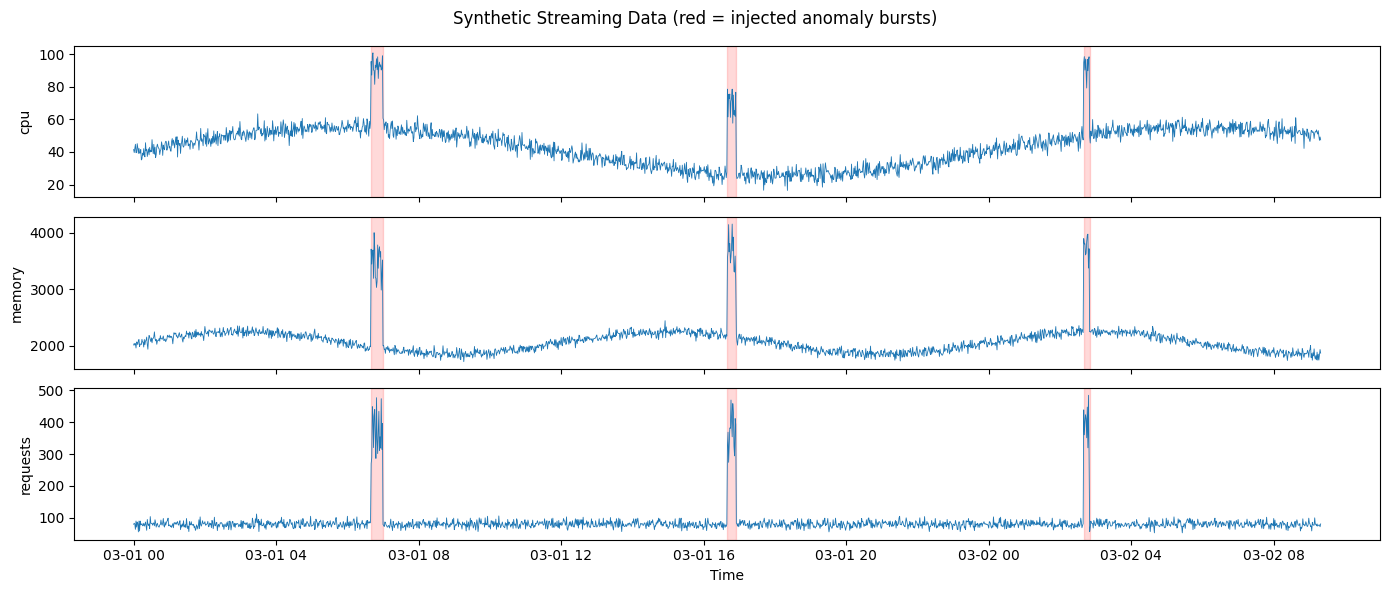

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, col in zip(axes, data_source.columns):
    ax.plot(data_source.index, data_source[col], linewidth=0.6)
    for start, end in burst_ranges:
        ax.axvspan(data_source.index[start], data_source.index[min(end, n_points-1)],
                   color='red', alpha=0.15)
    ax.set_ylabel(col)
axes[-1].set_xlabel('Time')
plt.suptitle('Synthetic Streaming Data (red = injected anomaly bursts)')
plt.tight_layout()
plt.show()

---
## 2. Define Events (optional)

Events are known incidents that can be overlaid on the real-time plot as colored vertical bands. Each event requires:
- `start` / `end`: timestamps defining the event window
- `color`: band color on the chart
- `label`: text annotation shown on the plot

In [4]:
events = pd.DataFrame({
    'start': ['2025-03-01 06:40:00', '2025-03-01 16:40:00', '2025-03-02 02:40:00'],
    'end':   ['2025-03-01 07:00:00', '2025-03-01 16:55:00', '2025-03-02 02:50:00'],
    'color': ['orange', 'red', 'purple'],
    'label': ['Burst 1 window', 'Burst 2 window', 'Burst 3 window'],
})

events

,start,end,color,label
0,2025-03-01 06:40:00,2025-03-01 07:00:00,orange,Burst 1 window
1,2025-03-01 16:40:00,2025-03-01 16:55:00,red,Burst 2 window
2,2025-03-02 02:40:00,2025-03-02 02:50:00,purple,Burst 3 window


---
## 3. Key Parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `data` | DataFrame | Source data to stream (time-indexed, numeric columns) |
| `chunk_size` | int | Number of rows per streaming batch. Smaller = more responsive, larger = more stable |
| `stream_interval` | float | Seconds between batches. Controls the simulation speed |
| `window_size` | int | Sliding window size for the detector. The model trains on this many recent points |
| `threshold` | float | Static anomaly score threshold. Scores above this are flagged |
| `dynamic_threshold` | bool | If `True`, uses percentile-based adaptive threshold instead of static |
| `percentile` | int | Percentile of historical scores used as threshold (only when `dynamic_threshold=True`) |
| `events` | DataFrame | Optional incident windows to overlay on the live chart |

### Choosing chunk_size and window_size

- `chunk_size` controls **latency**: smaller chunks = faster reaction, but noisier scores
- `window_size` controls **stability**: larger windows = more context for "normal", but slower adaptation
- A good starting point: `window_size = 2-3x chunk_size`

---
## 4. Run Simulation — Static Threshold

We configure the simulation with a fixed threshold of 0.15 and run it inline using `run_notebook()`. The chart updates after each chunk is processed:

- **Blue line**: anomaly scores over time (negated `decision_function`, so higher = more anomalous)
- **Orange dashed line**: threshold
- **Red dots**: samples exceeding the threshold
- **Colored bands**: event windows

Watch for score spikes when the timeline reaches the injected anomaly bursts (~index 400, 1000, 1600).

> `stream_interval=0.3` speeds up the animation. Set to `1` for real-time pacing.

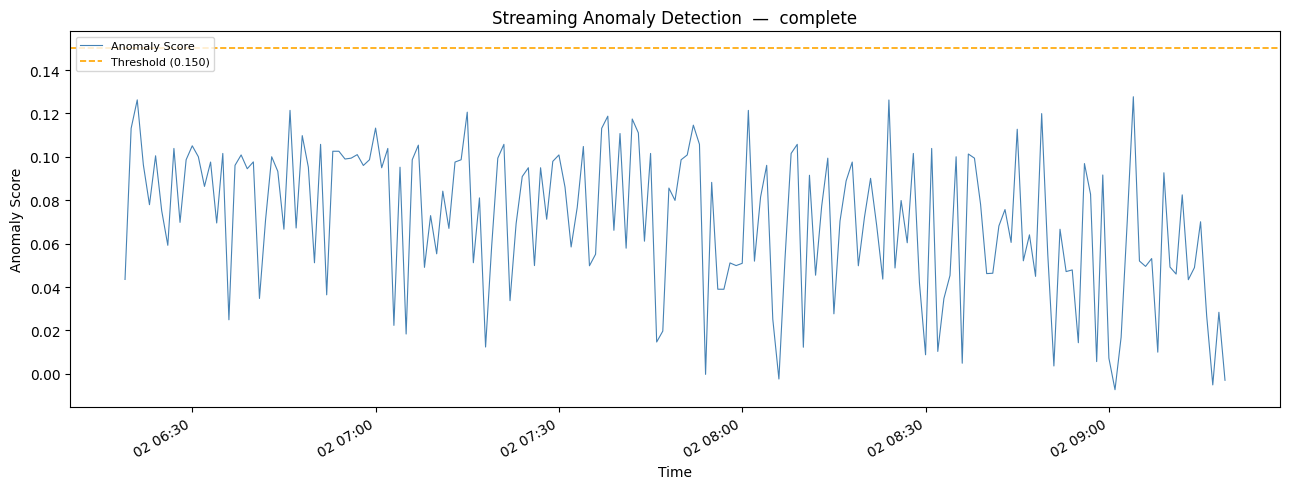

Simulation complete. Processed 40 chunks, total anomaly scores: 1900


In [5]:
from sentinel.simulation import StreamingSimulation

sim = StreamingSimulation(
    data=data_source,
    chunk_size=50,
    stream_interval=0.3,      # fast animation for demo
    window_size=120,
    threshold=0.15,
    dynamic_threshold=False,
    events=events,
)

sim.run_notebook()

---
## 5. Run Simulation — Dynamic Threshold

With `dynamic_threshold=True`, the threshold adapts based on the 95th percentile of all historical scores seen so far. This means:

- During stable periods, the threshold drops (tighter detection)
- During noisy periods, the threshold rises (fewer false positives)
- The orange dashed line moves as the simulation progresses

Compare the threshold behavior with the static run above.

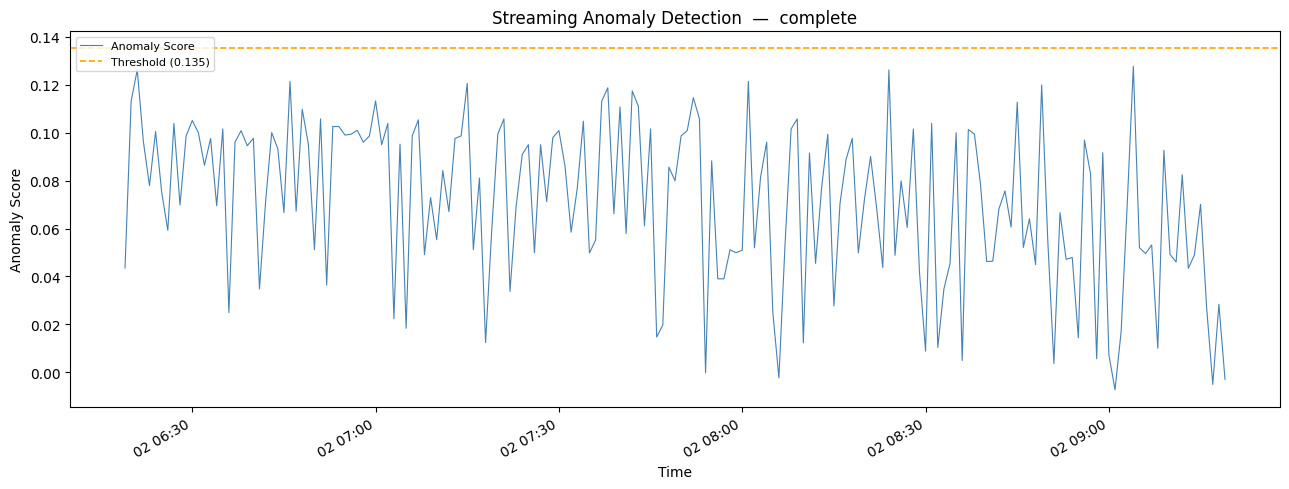

Simulation complete. Processed 40 chunks, total anomaly scores: 1900


In [6]:
sim_dynamic = StreamingSimulation(
    data=data_source,
    chunk_size=50,
    stream_interval=0.3,
    window_size=120,
    threshold=0.15,
    dynamic_threshold=True,
    percentile=95,
    events=events,
)

sim_dynamic.run_notebook()

---
## 6. Using StreamingDataManager Independently

The `StreamingDataManager` can be used on its own to build custom streaming pipelines. It runs a background thread that makes data chunks available via `get_next_chunk()`.

This is useful when you want to:
- Feed data to your own detector instead of the built-in IsolationForest
- Build a custom visualization or alerting system
- Integrate streaming data into a larger pipeline

In [7]:
from sentinel.simulation.streaming_anomaly_detection import StreamingDataManager
import time

manager = StreamingDataManager(data_source, chunk_size=100, stream_interval=0.1)
manager.start()

for i in range(3):
    time.sleep(0.15)
    chunk = manager.get_next_chunk()
    if chunk is not None:
        print(f"Chunk {i+1}: {chunk.shape[0]} rows, index {chunk.index[0]} → {chunk.index[-1]}")
    else:
        print(f"Chunk {i+1}: not ready yet")

manager.stop()
print("\nManager stopped.")

Chunk 1: 100 rows, index 2025-03-01 00:00:00 → 2025-03-01 01:39:00
Chunk 2: 100 rows, index 2025-03-01 01:40:00 → 2025-03-01 03:19:00
Chunk 3: 100 rows, index 2025-03-01 03:20:00 → 2025-03-01 04:59:00

Manager stopped.


---
## 7. Running as a Standalone Script

For a native matplotlib window with full interactivity (zoom, pan, resize), save the following as a `.py` file and run from your terminal:

```python
# streaming_demo.py
import numpy as np
import pandas as pd
from sentinel.simulation import StreamingSimulation

np.random.seed(42)
n = 2000
timestamps = pd.date_range('2025-03-01', periods=n, freq='1min')
t = np.arange(n)

data = pd.DataFrame({
    'cpu': 40 + 15 * np.sin(2 * np.pi * t / 1440) + np.random.normal(0, 3, n),
    'memory': 2048 + 200 * np.sin(2 * np.pi * t / 720) + np.random.normal(0, 50, n),
    'requests': np.random.poisson(80, n).astype(float),
}, index=timestamps)

# Inject anomalies
data.iloc[400:420] += [40, 1500, 300]

sim = StreamingSimulation(
    data=data,
    chunk_size=50,
    stream_interval=1,
    window_size=120,
    threshold=0.15,
)
sim.run()  # Press Ctrl+C to stop
```

```bash
python streaming_demo.py
```

---
## Summary

| Method | Environment | Animation |
|--------|-------------|----------|
| `run_notebook()` | Jupyter | Inline chart with `clear_output` |
| `run()` | Terminal script | Native matplotlib interactive window |

| Component | Use case |
|-----------|----------|
| `StreamingSimulation` | Full demo: streaming + detection + live chart |
| `StreamingDataManager` | Standalone data feeder for custom pipelines |
| `AnomalyDetector` | Internal IsolationForest wrapper |

### Key takeaways

- Use `run_notebook()` for Jupyter, `run()` for standalone scripts
- `dynamic_threshold=True` adapts to shifting baselines — reduces alert fatigue
- `StreamingDataManager` can be used independently to feed data to any detector
- The `events` parameter overlays known incidents for visual validation